# LSTM — H=2 log-return (top-3 family)

Ranking: every **H=6 barrier** run made RMSE worse. Top 3 are all **H=2 log-return**, RMSE **0.77**, dir ~50.5%. Rank 1 = MSE 5-d logrets; rank 2 = stacked LSTM + BCE (same RMSE, no extra dir). Longer window (200) did nothing.

This run stays in that family and only adds what those rows never combined:

- **Target:** 2-bar log return, **Huber + small sign BCE** (RMSE first, a little pressure on dir).
- **Net:** stacked `LSTM(64,32)` like rank 2, dropout 0.2.
- **Features:** 9-d logret + mid + TOD + range (not the 13-d session set).
- **All train bars**, light recency weights. No hit-filter, no class weights.

Weights: `models/lstm/`.


In [38]:
# Start .venv in terminal
# ----------------------
# .\.venv\Scripts\activate
# python -m ipykernel install --user --name=.venv --display-name "Python (.venv)"
# ----------------------

In [51]:
import json
import os
import random
import sys
from pathlib import Path

_ROOT = Path.cwd() if (Path.cwd() / "Data_Handling.py").exists() else Path.cwd().parent
    if not (_ROOT / "Data_Handling.py").exists() and (Path.cwd() / "Mario" / "Data_Handling.py").exists():
        _ROOT = Path.cwd() / "Mario"
    if not (_ROOT / "Data_Handling.py").exists() and (Path.cwd().parent / "Mario" / "Data_Handling.py").exists():
        _ROOT = Path.cwd().parent / "Mario"
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from Data_Handling import fetch_alpaca_vbt_data

np.random.seed(SEED)
tf.random.set_seed(SEED)


In [63]:
# -----------------------
# Config (matches live template defaults)
# -----------------------
SYMBOL = "SPY"
START = "2024-07-01"
END = "2026-05-01"
TIMEFRAME_UNIT = "Minute"
MULTIPLIER = 5

WINDOW = 78
HORIZON = 2
EPOCHS = 50
BATCH_SIZE = 64
PATIENCE = 8

MIN_EXPECTED_MOVE_PCT = 0.000
DIRECTION = "both"
TARGET_PCT = 0.002
STOP_PCT = 0.002
FLATTEN_AFTER_ET = "15:55"

FEATURES = "logret_mid_tod_range"
N_FEATS = 9
LSTM_UNITS = (64, 32)
DROPOUT = 0.2
HUBER_DELTA = 1.0
DIR_COEF = 0.08  # extra sign pressure; keep small so RMSE stays the ranking metric
RECENCY_HALFLIFE = 0.50
CLIPNORM = 5.0
LEARNING_RATE = 1e-3
EMBARGO = WINDOW + HORIZON

MODEL_DIR = _ROOT / "models" / "lstm"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "model.h5"
SCALER_PATH = MODEL_DIR / "scaler.json"
TARGET_SCALER_PATH = MODEL_DIR / "target_scaler.json"


In [64]:
df = fetch_alpaca_vbt_data(
    symbol=SYMBOL,
    start=START,
    end=END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER,
)
ohlcv = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=np.float64)
closes = ohlcv[:, 3]
print(df.tail())
print(f"bars={len(df):,}  {df.index.min()} → {df.index.max()}")

field                          Open      High     Low    Close   Volume
timestamp                                                              
2026-04-30 23:35:00+00:00  720.1400  720.2500  720.13  720.130   5681.0
2026-04-30 23:40:00+00:00  720.1410  720.1500  720.01  720.010   6311.0
2026-04-30 23:45:00+00:00  719.9600  720.1300  719.96  720.051   2490.0
2026-04-30 23:50:00+00:00  720.0999  720.1932  719.89  719.890   3484.0
2026-04-30 23:55:00+00:00  719.9300  719.9700  719.60  719.870  13457.0
bars=87,119  2024-07-01 08:00:00+00:00 → 2026-04-30 23:55:00+00:00


## Windows

9-d log-return windows, **2-bar** log-return target. Chrono 70/15/15 + embargo. Barrier labels are printed only as a mix diagnostic.


In [ ]:
if "ohlcv" not in globals() or "df" not in globals():
    df = fetch_alpaca_vbt_data(
        symbol=SYMBOL,
        start=START,
        end=END,
        timeframe_unit=TIMEFRAME_UNIT,
        multiplier=MULTIPLIER,
    )
    ohlcv = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=np.float64)
    closes = ohlcv[:, 3]
    print(f"bars={len(df):,}  {df.index.min()} → {df.index.max()}")


def ohlcv_to_log_features(ohlcv: np.ndarray, index) -> np.ndarray:
    o, h, l, c, v = (ohlcv[:, i] for i in range(5))
    c_prev = np.empty_like(c)
    c_prev[0] = c[0]
    c_prev[1:] = c[:-1]
    v_prev = np.empty_like(v)
    v_prev[0] = np.maximum(v[0], 1.0)
    v_prev[1:] = np.maximum(v[:-1], 1.0)
    c_prev = np.maximum(c_prev, 1e-12)
    v = np.maximum(v, 1.0)
    mid = np.maximum((h + l) / 2.0, 1e-12)
    et = pd.DatetimeIndex(index)
    if et.tz is None:
        et = et.tz_localize("UTC")
    et = et.tz_convert("America/New_York")
    minutes = et.hour.to_numpy() * 60 + et.minute.to_numpy()
    ang = 2.0 * np.pi * minutes / (24.0 * 60.0)
    log_range = np.log(np.maximum(h, 1e-12) / np.maximum(l, 1e-12))
    return np.stack(
        [
            np.log(o / c_prev),
            np.log(h / c_prev),
            np.log(l / c_prev),
            np.log(c / c_prev),
            np.log(v / v_prev),
            np.log(mid / c_prev),
            np.sin(ang),
            np.cos(ang),
            log_range,
        ],
        axis=1,
    )


def make_windows_returns_hstep(ohlcv: np.ndarray, index, window: int = 200, horizon: int = 8):
    close = ohlcv[:, 3]
    feats = ohlcv_to_log_features(ohlcv, index)
    n = len(ohlcv)
    n_win = n - window - horizon + 1
    Xs = np.lib.stride_tricks.sliding_window_view(feats, window, axis=0)[:n_win]
    Xs = np.ascontiguousarray(np.transpose(Xs, (0, 2, 1)))
    t_idx = np.arange(window - 1, window - 1 + n_win)
    c_t = close[t_idx]
    c_j = close[t_idx + horizon]
    valid = np.isfinite(c_t) & np.isfinite(c_j) & (c_t > 0) & (c_j > 0)
    y = np.log(c_j / c_t)
    return Xs[valid], y[valid], t_idx[valid]


def chrono_split_embargo(n: int, train_frac: float = 0.70, val_frac: float = 0.15, embargo: int = 0):
    i70 = int(train_frac * n)
    i85 = int((train_frac + val_frac) * n)
    return slice(0, i70), slice(i70 + embargo, i85), slice(i85 + embargo, n)


def first_barrier_labels(ohlcv: np.ndarray, t_idx: np.ndarray, horizon: int, target_pct: float, stop_pct: float) -> np.ndarray:
    """0 timeout/ambiguous, 1 upside first, 2 downside first. Matches sim first-touch."""
    y = np.zeros(len(t_idx), dtype=np.int32)
    high, low, close = ohlcv[:, 1], ohlcv[:, 2], ohlcv[:, 3]
    n_bars = len(ohlcv)
    for k, t in enumerate(t_idx):
        t = int(t)
        entry = close[t]
        tp_px = entry * (1.0 + target_pct)
        sl_px = entry * (1.0 - stop_pct)
        cls = 0
        for j in range(1, horizon + 1):
            i = t + j
            if i >= n_bars:
                break
            hit_up = high[i] >= tp_px
            hit_dn = low[i] <= sl_px
            if hit_up and hit_dn:
                cls = 0
                break
            if hit_up:
                cls = 1
                break
            if hit_dn:
                cls = 2
                break
        y[k] = cls
    return y


X_all, y_all, t_all = make_windows_returns_hstep(ohlcv, df.index, WINDOW, HORIZON)
assert X_all.shape[1:] == (WINDOW, N_FEATS), X_all.shape
y_cls_all = first_barrier_labels(ohlcv, t_all, HORIZON, TARGET_PCT, STOP_PCT)
print(f"X_all shape: {X_all.shape}  y_all shape: {y_all.shape}  features={FEATURES}")
print(
    "barrier mix timeout/up/down:",
    float((y_cls_all == 0).mean()),
    float((y_cls_all == 1).mean()),
    float((y_cls_all == 2).mean()),
)

train_sl, val_sl, test_sl = chrono_split_embargo(len(X_all), embargo=EMBARGO)
X_train, y_train, t_train = X_all[train_sl], y_all[train_sl], t_all[train_sl]
X_val, y_val, t_val = X_all[val_sl], y_all[val_sl], t_all[val_sl]
X_test, y_test, t_test = X_all[test_sl], y_all[test_sl], t_all[test_sl]
y_cls_train, y_cls_val, y_cls_test = y_cls_all[train_sl], y_cls_all[val_sl], y_cls_all[test_sl]
print(f"split: {len(X_train)} / {len(X_val)} / {len(X_test)} train/val/test  embargo={EMBARGO}")



X_all shape: (87040, 78, 9)  y_all shape: (87040,)  features=logret_mid_tod_range
barrier mix timeout/up/down: 0.9039751838235294 0.04337086397058824 0.05265395220588235
split: 60927 / 12977 / 12976 train/val/test  embargo=80


## Scalers

Feature and target `StandardScaler` on **all** training windows (same as rank 1). Light recency `sample_weight`. Fit the net on every train bar.


In [66]:
feature_scaler = StandardScaler()
feature_scaler.fit(X_train.reshape(-1, N_FEATS))

target_scaler = StandardScaler()
y_train_s = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_s = target_scaler.transform(y_val.reshape(-1, 1)).ravel()


def scale_windows(X: np.ndarray) -> np.ndarray:
    return feature_scaler.transform(X.reshape(-1, N_FEATS)).reshape(X.shape)


def recency_weights(t_idx: np.ndarray, half_life: float) -> np.ndarray:
    t = t_idx.astype(np.float64)
    t = (t - t.min()) / max(float(t.max() - t.min()), 1.0)
    return np.power(2.0, (t - 1.0) / max(half_life, 1e-3)).astype(np.float32)


X_train_s = scale_windows(X_train)
X_val_s = scale_windows(X_val)
X_test_s = scale_windows(X_test)
X_train_fit, y_train_fit = X_train_s, y_train_s.astype(np.float32)
X_val_fit, y_val_fit = X_val_s, y_val_s.astype(np.float32)
w_train = recency_weights(t_train, RECENCY_HALFLIFE)
print(f"fit on all train bars: {len(y_train_fit):,} / {len(y_val_fit):,} val  weight mean={float(w_train.mean()):.3f}")
print("feature mean:", np.round(feature_scaler.mean_, 4))
print("target mean/scale:", float(target_scaler.mean_[0]), float(target_scaler.scale_[0]))


fit on all train bars: 60,927 / 12,977 val  weight mean=0.541
feature mean: [ 0.000e+00  4.000e-04 -4.000e-04  0.000e+00  0.000e+00 -0.000e+00
  2.200e-03 -4.229e-01  8.000e-04]
target mean/scale: 6.350620977296137e-06 0.0011637917148944838


In [67]:
def huber_sign_loss(y_true, y_pred):
    h = tf.keras.losses.Huber(delta=HUBER_DELTA, reduction="none")(y_true, y_pred)
    p = tf.sigmoid(y_pred)
    y01 = tf.cast(y_true > 0.0, tf.float32)
    bce = tf.keras.losses.BinaryCrossentropy(reduction="none")(y01, p)
    return h + DIR_COEF * bce


model = Sequential(
    [
        Input(shape=(WINDOW, N_FEATS)),
        LSTM(LSTM_UNITS[0], return_sequences=True, dropout=DROPOUT),
        LSTM(LSTM_UNITS[1], return_sequences=False, dropout=DROPOUT),
        Dropout(DROPOUT),
        Dense(16, activation="relu"),
        Dense(1),
    ]
)
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM),
    loss=huber_sign_loss,
    metrics=["mae"],
)
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 78, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
    ),
]

history = model.fit(
    X_train_fit,
    y_train_fit,
    sample_weight=w_train,
    validation_data=(X_val_fit, y_val_fit),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/50


952/952 - 62s - 65ms/step - loss: 0.1635 - mae: 0.5102 - val_loss: 0.2423 - val_mae: 0.4274 - learning_rate: 0.0010
Epoch 2/50


952/952 - 53s - 56ms/step - loss: 0.1631 - mae: 0.5085 - val_loss: 0.2423 - val_mae: 0.4274 - learning_rate: 0.0010
Epoch 3/50
952/952 - 55s - 58ms/step - loss: 0.1630 - mae: 0.5084 - val_loss: 0.2436 - val_mae: 0.4294 - learning_rate: 0.0010
Epoch 4/50


952/952 - 55s - 58ms/step - loss: 0.1630 - mae: 0.5084 - val_loss: 0.2423 - val_mae: 0.4274 - learning_rate: 0.0010
Epoch 5/50
952/952 - 91s - 95ms/step - loss: 0.1630 - mae: 0.5083 - val_loss: 0.2423 - val_mae: 0.4274 - learning_rate: 0.0010
Epoch 6/50

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
952/952 - 56s - 59ms/step - loss: 0.1630 - mae: 0.5083 - val_loss: 0.2423 - val_mae: 0.4274 - learning_rate: 0.0010
Epoch 7/50
952/952 - 55s - 58ms/step - loss: 0.1630 - mae: 0.5082 - val_loss: 0.2423 - val_mae: 0.4274 - learning_rate: 5.0000e-04
Epoch 8/50
952/952 - 58s - 61ms/step - loss: 0.1630 - mae: 0.5083 - val_loss: 0.2423 - val_mae: 0.4274 - learning_rate: 5.0000e-04
Epoch 9/50
952/952 - 64s - 67ms/step - loss: 0.1630 - mae: 0.5082 - val_loss: 0.2423 - val_mae: 0.4274 - learning_rate: 5.0000e-04
Epoch 10/50
952/952 - 45s - 47ms/step - loss: 0.1630 - mae: 0.5083 - val_loss: 0.2423 - val_mae: 0.4274 - learning_rate: 5.0000e-04
Epoch 11/50

Epoch 11: Reduc

## Test metrics

Price-space RMSE/MAE/MAPE from inverse-scaled log-return preds. **Dir acc** = sign match vs true 2-bar log return. `dir_acc_conf` uses `|pred move| > 1 bps`.


In [69]:
def evaluate_split(name: str, X_s: np.ndarray, y_true_log: np.ndarray, t_idx: np.ndarray):
    pred_s = model.predict(X_s, verbose=0).ravel()
    pred_log = target_scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    c_t = closes[t_idx]
    c_true = c_t * np.exp(y_true_log)
    c_pred = c_t * np.exp(pred_log)
    move_pct = np.exp(pred_log) - 1.0

    rmse = float(np.sqrt(mean_squared_error(c_true, c_pred)))
    mae = float(mean_absolute_error(c_true, c_pred))
    mape = float(mean_absolute_percentage_error(c_true, c_pred))
    dir_acc = float(np.mean(np.sign(pred_log) == np.sign(y_true_log)))
    conf = np.abs(move_pct) > 0.0001
    dir_acc_conf = float(np.mean(np.sign(pred_log[conf]) == np.sign(y_true_log[conf]))) if conf.any() else float("nan")
    print(
        f"{name}: RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.4%}  "
        f"dir_acc={dir_acc:.3f}  dir_acc_conf={dir_acc_conf:.3f} (n={int(conf.sum())})"
    )
    return {
        "pred_log": pred_log,
        "true_log": y_true_log,
        "c_t": c_t,
        "c_true": c_true,
        "c_pred": c_pred,
        "move_pct": move_pct,
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "dir_acc": dir_acc,
    }


train_eval = evaluate_split("train", X_train_s, y_train, t_train)
val_eval = evaluate_split("val  ", X_val_s, y_val, t_val)
test_eval = evaluate_split("test ", X_test_s, y_test, t_test)


train: RMSE=0.6458  MAE=0.3408  MAPE=0.0591%  dir_acc=0.505  dir_acc_conf=nan (n=0)
val  : RMSE=0.5715  MAE=0.3368  MAPE=0.0497%  dir_acc=0.505  dir_acc_conf=nan (n=0)
test : RMSE=0.7692  MAE=0.4385  MAPE=0.0647%  dir_acc=0.499  dir_acc_conf=nan (n=0)


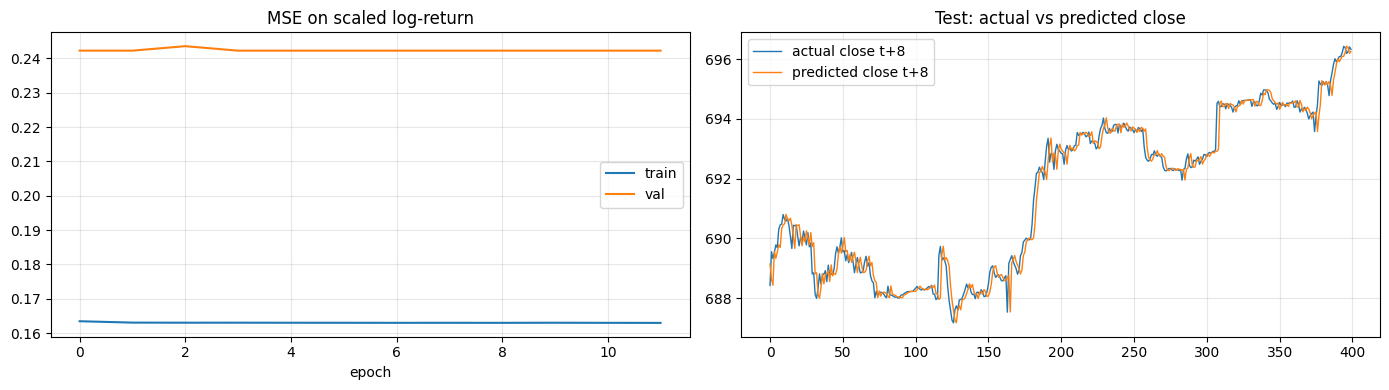

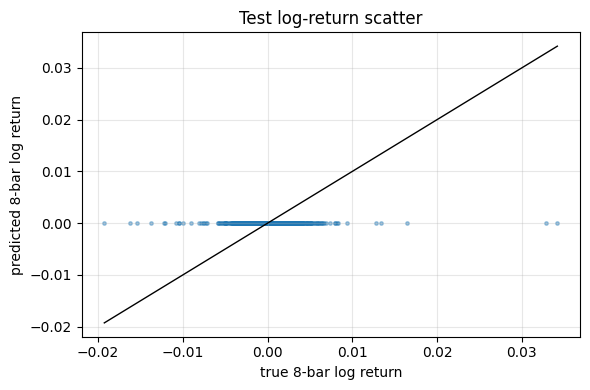

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("MSE on scaled log-return")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

n_plot = min(400, len(test_eval["c_true"]))
axes[1].plot(test_eval["c_true"][:n_plot], label="actual close t+8", linewidth=1)
axes[1].plot(test_eval["c_pred"][:n_plot], label="predicted close t+8", linewidth=1)
axes[1].set_title("Test: actual vs predicted close")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(test_eval["true_log"], test_eval["pred_log"], s=6, alpha=0.4)
lims = [
    min(test_eval["true_log"].min(), test_eval["pred_log"].min()),
    max(test_eval["true_log"].max(), test_eval["pred_log"].max()),
]
plt.plot(lims, lims, color="black", linewidth=1)
plt.xlabel("true 8-bar log return")
plt.ylabel("predicted 8-bar log return")
plt.title("Test log-return scatter")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Signals and triple-barrier backtest (test tail only)

Entry from the **predicted 2-bar move**: long/short if `|move| >= MIN_EXPECTED_MOVE_PCT`. TP/SL still 0.20% like rank 1. Flatten after 15:55 ET.


In [71]:
def signal_from_move(move_pct: float, min_move: float, direction: str = "both") -> int:
    if abs(move_pct) < min_move:
        return 0
    if move_pct > 0 and direction in ("long_only", "both"):
        return 1
    if move_pct < 0 and direction in ("short_only", "both"):
        return -1
    return 0


def is_flatten_bar(ts) -> bool:
    et = pd.Timestamp(ts)
    if et.tzinfo is None:
        et = et.tz_localize("UTC")
    et = et.tz_convert("America/New_York")
    hhmm = et.strftime("%H:%M")
    return hhmm >= FLATTEN_AFTER_ET


pred_by_t = {int(t): float(m) for t, m in zip(t_test, test_eval["move_pct"])}

start_i = int(t_test.min())
end_i = int(t_test.max())

in_pos = False
side = 0
entry_price = 0.0
entry_i = 0
expected_at_entry = 0.0
trades = []
equity = 1.0
curve = []

for i in range(start_i, end_i + 1):
    high, low, close = ohlcv[i, 1], ohlcv[i, 2], ohlcv[i, 3]
    ts = df.index[i]

    if in_pos:
        if side == 1:
            tp, sl = entry_price * (1 + TARGET_PCT), entry_price * (1 - STOP_PCT)
            hit_sl, hit_tp = low <= sl, high >= tp
        else:
            tp, sl = entry_price * (1 - TARGET_PCT), entry_price * (1 + STOP_PCT)
            hit_sl, hit_tp = high >= sl, low <= tp

        exit_price = None
        reason = None
        if hit_sl and hit_tp:
            exit_price, reason = sl, "ambiguous_sl"
        elif hit_sl:
            exit_price, reason = sl, "sl"
        elif hit_tp:
            exit_price, reason = tp, "tp"
        elif (i - entry_i) >= HORIZON:
            exit_price, reason = close, "timeout"
        elif is_flatten_bar(ts):
            exit_price, reason = close, "flatten_close"

        if exit_price is not None:
            ret = side * (exit_price / entry_price - 1.0)
            equity *= 1.0 + ret
            trades.append(
                {
                    "entry_time": df.index[entry_i],
                    "exit_time": ts,
                    "side": "long" if side == 1 else "short",
                    "entry": entry_price,
                    "exit": exit_price,
                    "ret": ret,
                    "reason": reason,
                    "expected_move_pct": expected_at_entry,
                    "bars_held": i - entry_i,
                }
            )
            in_pos = False
            side = 0
        curve.append((ts, equity))
        continue

    packed = pred_by_t.get(i)
    if packed is None:
        curve.append((ts, equity))
        continue
    move_pct = packed
    sig = signal_from_move(move_pct, MIN_EXPECTED_MOVE_PCT, DIRECTION)
    if sig != 0 and not is_flatten_bar(ts):
        in_pos = True
        side = sig
        entry_price = close
        entry_i = i
        expected_at_entry = float(move_pct)

    curve.append((ts, equity))

trades_df = pd.DataFrame(trades)
print(f"trades={len(trades_df)}  final_equity={equity:.4f}")
if len(trades_df):
    print(trades_df["reason"].value_counts().to_string())
    print(f"win_rate={(trades_df['ret'] > 0).mean():.3f}  mean_ret={trades_df['ret'].mean():.5f}")
    print(f"longs={(trades_df['side']=='long').sum()}  shorts={(trades_df['side']=='short').sum()}")
    display(trades_df.head())


trades=3293  final_equity=1.0006
reason
timeout          2840
sl                222
tp                207
flatten_close      17
ambiguous_sl        7
win_rate=0.499  mean_ret=0.00000
longs=3293  shorts=0


,entry_time,exit_time,side,entry,exit,ret,reason,expected_move_pct,bars_held
0,2026-01-23 15:05:00+00:00,2026-01-23 15:15:00+00:00,long,689.120,688.425,-0.001009,timeout,0.000028,2
1,2026-01-23 15:20:00+00:00,2026-01-23 15:30:00+00:00,long,689.555,689.530,-0.000036,timeout,0.000010,2
2,2026-01-23 15:35:00+00:00,2026-01-23 15:45:00+00:00,long,689.780,690.310,0.000768,timeout,0.000009,2
3,2026-01-23 15:50:00+00:00,2026-01-23 16:00:00+00:00,long,690.450,690.800,0.000507,timeout,0.000009,2
4,2026-01-23 16:05:00+00:00,2026-01-23 16:15:00+00:00,long,690.635,690.670,0.000051,timeout,0.000009,2


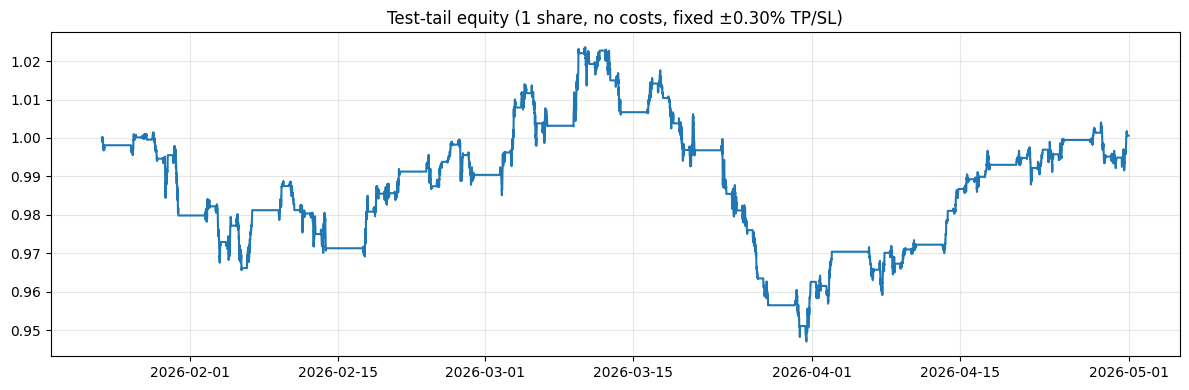

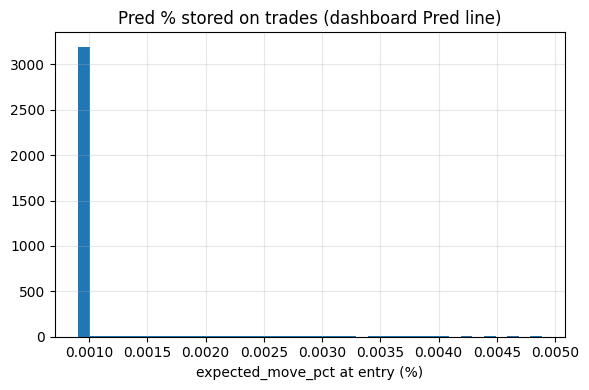

In [72]:
if curve:
    eq = pd.Series({t: e for t, e in curve})
    plt.figure(figsize=(12, 4))
    plt.plot(eq.index, eq.values)
    plt.title("Test-tail equity (1 share, no costs, fixed ±0.30% TP/SL)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if len(trades_df):
    plt.figure(figsize=(6, 4))
    plt.hist(trades_df["expected_move_pct"] * 100, bins=40)
    plt.xlabel("expected_move_pct at entry (%)")
    plt.title("Pred % stored on trades (dashboard Pred line)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [73]:
def dump_scaler(scaler: StandardScaler, path: Path):
    payload = {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "n_features_in": int(scaler.n_features_in_),
    }
    path.write_text(json.dumps(payload, indent=2))


model.save(MODEL_PATH)
dump_scaler(feature_scaler, SCALER_PATH)
dump_scaler(target_scaler, TARGET_SCALER_PATH)
print(f"saved {MODEL_PATH}")
print(f"saved {SCALER_PATH}")
print(f"saved {TARGET_SCALER_PATH}")

saved c:\Mario\Projects\MoneyTalk\Trading ML\Trading-for-Dummies-test-\models\lstm\model.h5
saved c:\Mario\Projects\MoneyTalk\Trading ML\Trading-for-Dummies-test-\models\lstm\scaler.json
saved c:\Mario\Projects\MoneyTalk\Trading ML\Trading-for-Dummies-test-\models\lstm\target_scaler.json
